In [1]:
from mdcrow import MDCrow
from langchain.callbacks import get_openai_callback
from datetime import datetime
import os 
import traceback

In [2]:
import sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '../'))
sys.path.append(parent_dir)
from robustness_prompts import get_prompt # noqa: E402

prompt_10_natural = get_prompt("natural", 10)

prompt_10_natural

'Simulate 1LYZ for 1ps at 300 K and for 1ps at 400K. Report the secondary structure assignments of the downloaded PDB structure and any known binding or active sites. Compute RMSD and radius of gyration of both simulations. Compute SASA for the 300K simulation.'

In [3]:
llm_model = "gpt-4-1106-preview"
tools = "all"

In [4]:
agent = MDCrow(
    agent_type="Structured", 
    model=llm_model, 
    top_k_tools=tools, 
    use_memory=False,
    streaming=False,
    verbose=True,
)
with get_openai_callback() as cb:
    chat_start = datetime.now()
    try:
        response = agent.run(prompt_10_natural, callbacks=[cb])
        print(response)
    except Exception as e:
        exc_type, exc_value, exc_traceback = sys.exc_info()
        print(f'{type(e).__name__}:{e}')
        print("".join(traceback.format_exception(exc_type, exc_value, exc_traceback)))
    chat_end = datetime.now()
    total_runtime = (chat_end - chat_start).total_seconds()
    print(cb)
    print(f"Total runtime: {total_runtime:.2f}s")



> Entering new AgentExecutor chain...


Thought: The task involves multiple steps: simulating the protein 1LYZ at two different temperatures, analyzing the secondary structure, identifying known binding or active sites, and computing RMSD, radius of gyration, and SASA for the specified simulations. I will start by downloading the PDB structure of 1LYZ using the PDBFileDownloader tool.

Action:
```
{
    "action": "PDBFileDownloader",
    "action_input": {
        "query": "1LYZ"
    }
}
```PDB file found with this ID: 1LYZ

Observation: Succeeded. Downloaded the PDB file:1LYZ_213816
Thought:

Now that I have the PDB file for 1LYZ, I need to set up and run two separate molecular dynamics simulations: one at 300K and another at 400K, each for 1 picosecond. I will use the SetUpandRunFunction tool to perform these simulations. Since the simulations are short, I will run them sequentially, starting with the 300K simulation. After the simulations, I will proceed with the analysis of the secondary structure, RMSD, radius of gyration, and SASA as requested.

Action:
```
{
    "action": "SetUpandRunFunction",
    "action_input": {
        "pdb_id": "1LYZ_213816",
        "forcefield_files": ["amber99sbildn.xml", "tip3p.xml"],
        "save": true,
        "system_params": {
            "nonbondedMethod": "PME",
            "nonbondedCutoff": "1 * nanometers",
            "constraints": "HBonds",
            "rigidWater": true,
            "solvate": true
        },
        "integrator_params": {
            "integrator_type": "LangevinMiddle",
            "Temperature": "300 * kelvi

The previous attempt to run the simulation failed because the constraintTolerance parameter was not specified. I need to correct this and try running the simulation again at 300K for 1 picosecond. I will include the constraintTolerance parameter this time.

Action:
```
{
    "action": "SetUpandRunFunction",
    "action_input": {
        "pdb_id": "1LYZ_213816",
        "forcefield_files": ["amber99sbildn.xml", "tip3p.xml"],
        "save": true,
        "system_params": {
            "nonbondedMethod": "PME",
            "nonbondedCutoff": "1 * nanometers",
            "constraints": "HBonds",
            "rigidWater": true,
            "constraintTolerance": 0.00001,
            "solvate": true
        },
        "integrator_params": {
            "integrator_type": "LangevinMiddle",
            "Temperature": "300 * kelvin",
            "Friction": "1.0 / picoseconds",
            "Timestep": "0.002 * picoseconds"
        },
        "simulation_params": {
            "Ensemble": "NVT

About to create system...
Attempts at creating system: 0/3
Error adding solvent ValueError – No template found for residue 1 (LYS).  The set of atoms is similar to HID, but it is missing 8 atoms.  For more information, see https://github.com/openmm/openmm/wiki/Frequently-Asked-Questions#template
Residue code: LYS
Residue code not in solvent list. Adding forcefield                         not supported.

Observation: Failed. No template found for residue 1 (LYS).  The set of atoms is similar to HID, but it is missing 8 atoms.  For more information, see https://github.com/openmm/openmm/wiki/Frequently-Asked-Questions#templateThis were the inputs {'pdb_id': '1LYZ_213816', 'forcefield_files': ['amber99sbildn.xml', 'tip3p.xml'], 'save': True, 'system_params': {'nonbondedMethod': 'PME', 'nonbondedCutoff': '1 * nanometers', 'constraints': 'HBonds', 'rigidWater': True, 'constraintTolerance': 1e-05, 'solvate': True}, 'integrator_params': {'integrator_type': 'LangevinMiddle', 'Temperature': '300

...

The radius of gyration for the 400K simulation has been computed successfully. Now I will compute the Solvent Accessible Surface Area (SASA) for the 300K simulation using the SolventAccessibleSurfaceArea tool.

Action:
```
{
    "action": "SolventAccessibleSurfaceArea",
    "action_input": {
        "top_fileid": "top_sim0_213845",
        "traj_fileid": "rec0_213850",
        "molecule_name": "1LYZ"
    }
}
```Loading trajectory ...


Calculating SASA ...
Data saved to /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_10/records/sasa_1LYZ.csv


SASA plot saved to FIG_sasa_1LYZ_20251222_223601.png

Observation: Succeeded. SASA values computed and saved with File ID sasa_1LYZ. SASA analysis completed. Saved the plot with plot ID fig0_223601. 
Thought:

Final Answer: The molecular dynamics simulations of protein 1LYZ at 300K and 400K for 1 picosecond each have been successfully completed. The secondary structure analysis revealed the presence of helices, strands, and coils. No known binding sites were identified, but two active sites were found at residues 53 and 71. The RMSD values for the 300K and 400K simulations were calculated and saved with file IDs rmsd_213845 and rmsd_215349, respectively. The average radius of gyration was found to be 3.45 nm for the 300K simulation and 3.44 nm for the 400K simulation. The Solvent Accessible Surface Area (SASA) for the 300K simulation was computed and saved with File ID sasa_1LYZ.

> Finished chain.
({'input': '\n    You are an expert molecular dynamics scientist, and\n    your task is to respond to the question or\n    solve the problem to the best of your ability using\n    the provided tools.\n\n    You can only respond with a single complete\n    \'Thought, Action, Action Input\' format\n

<Figure size 640x480 with 0 Axes>

In [3]:
registry = agent.path_registry
print(registry.list_path_names_and_descriptions().replace(",", "\n"))

Files found in registry: 1LYZ_213816: PDB file downloaded from RSCB
 PDBFile ID: 1LYZ_213816
 1LYZ_213837: Cleaned File:  Removed Heterogens
 and Water Removed.  Replaced Nonstandard Residues. Added Hydrogens at pH 7.0. Missing Atoms added and nonstandard residues replaced. 
 top_sim0_213845: Initial positions for simulation sim0_213845
 sim0_213845: Basic Simulation of Protein 1LYZ_213837
 rec0_213850: Simulation trajectory for protein 1LYZ_213837 and simulation sim0_213845
 rec1_213850: Simulation state log for protein 1LYZ_213837 and simulation sim0_213845
 rec2_213850: Simulation pdb frames for protein 1LYZ_213837 and simulation sim0_213845
 top_sim0_215349: Initial positions for simulation sim0_215349
 sim0_215349: Basic Simulation of Protein 1LYZ_213837
 rec0_215355: Simulation trajectory for protein 1LYZ_213837 and simulation sim0_215349
 rec1_215355: Simulation state log for protein 1LYZ_213837 and simulation sim0_215349
 rec2_215355: Simulation pdb frames for protein 1LYZ_2138

In [4]:
# make sure pdb was downloaded
assert os.path.exists(registry.get_mapped_path("1LYZ_213816"))

In [5]:
# make sure dssp was computed correctly
from mdcrow.tools.base_tools import ComputeDSSP

dssp = ComputeDSSP(registry)
dssp._run(traj_file= "1LYZ_213816", target_frames="first")

"{'residues in helix': 50, 'residues in strand': 14, 'residues in coil': 65, 'residues not assigned, not a protein residue': 101}"

In [9]:
# make sure the sites were found
from mdcrow.tools.base_tools import GetAllKnownSites

get_all_known_sites = GetAllKnownSites()
get_all_known_sites._run(query="1LYZ", primary_accession="")

"Active Sites: [{'start': 53, 'start_modifier': 'EXACT', 'end': 53, 'end_modifier': 'EXACT', 'description': '', 'evidences': [{'evidenceCode': 'ECO:0000255', 'source': 'PROSITE-ProRule', 'id': 'PRU00680'}]}, {'start': 71, 'start_modifier': 'EXACT', 'end': 71, 'end_modifier': 'EXACT', 'description': '', 'evidences': [{'evidenceCode': 'ECO:0000255', 'source': 'PROSITE-ProRule', 'id': 'PRU00680'}]}]\nNo known binding sites.\nNo other relevant sites."

In [6]:
# make sure trajectory and topology exist
traj_path_1 = registry.get_mapped_path("rec0_213850")
top_path_1 = registry.get_mapped_path("top_sim0_213845")

assert os.path.exists(traj_path_1)
assert os.path.exists(top_path_1)

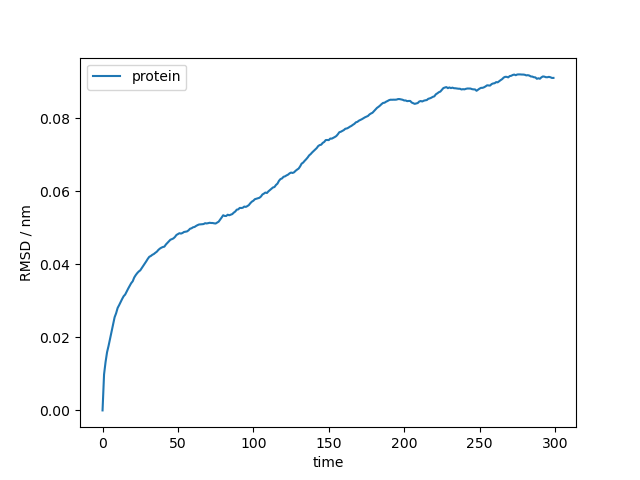

In [8]:
# make sure rmsd plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_221058'))

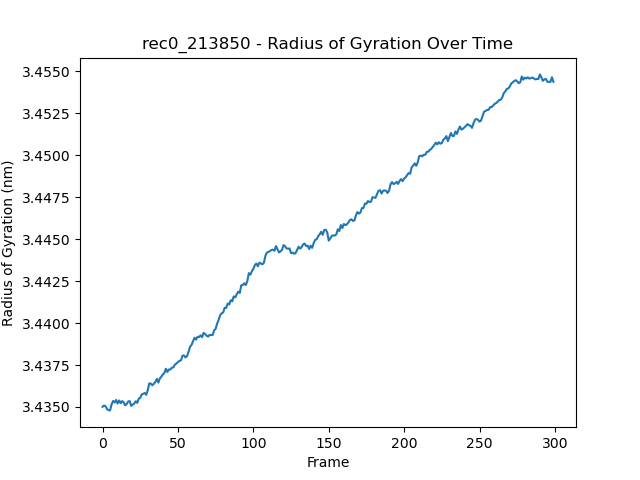

In [10]:
# make sure rgy plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_221109'))

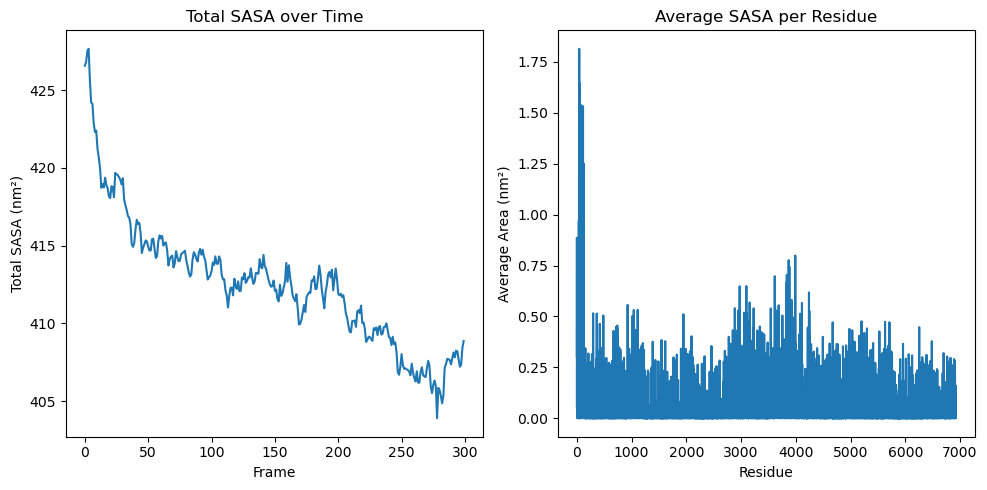

In [12]:
# make sure sasa plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_223601'))

In [7]:
# make sure trajectory and topology exist (sim2)
traj_path_2 = registry.get_mapped_path("rec0_215355")
top_path_2 = registry.get_mapped_path("top_sim0_215349")

assert os.path.exists(traj_path_2)
assert os.path.exists(top_path_2)

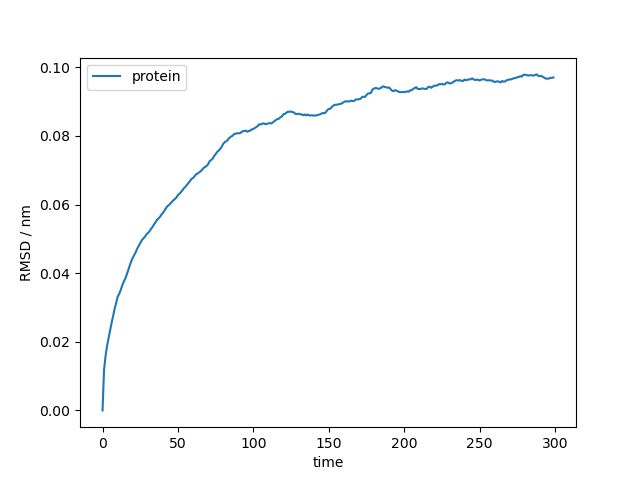

In [9]:
# make sure rmsd plot was generated (sim2)
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_221104'))

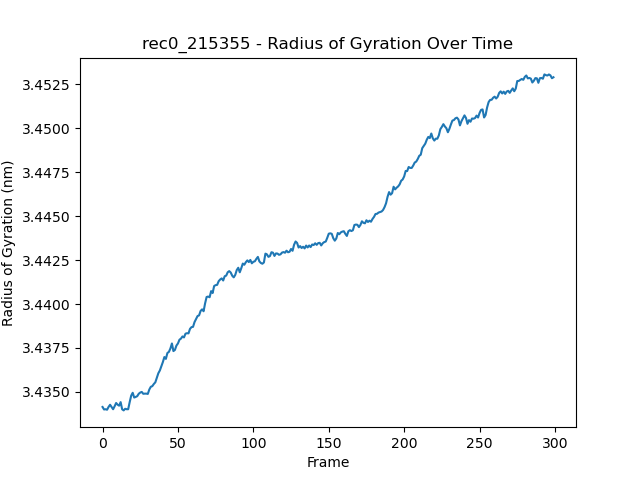

In [11]:
# make sure rgy plot was generated (sim2)
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_221114'))

In [17]:
#verify the total cost
def calculate_llm_cost(input_tokens, output_tokens, model):
    pricing_2024 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 5/1e6, "output": 15/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
        "claude-3-opus": {"input": 15/1e6, "output": 75/1e6},
        "claude-3.5-sonnet": {"input": 3/1e6, "output": 15/1e6},
    }
    pricing_2025 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 2.5/1e6, "output": 10/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
    }
    
    prices = pricing_2025[model]
    cost = (input_tokens * prices["input"]) + (output_tokens * prices["output"])
    return round(cost, 6)

llm_cost = calculate_llm_cost(cb.prompt_tokens, cb.completion_tokens, agent.llm.model_name)
print('Input tokens:',cb.prompt_tokens)
print('Output tokens:',cb.completion_tokens)
print('LLM costs: $',llm_cost)

Input tokens: 145898
Output tokens: 2704
LLM costs: $ 1.5401
